# 02. Long-Article Extension Experiments

This notebook evaluates practical alternatives for articles longer than the 1024-token input limit used by the main BART model.

Methods compared on the same long-article subset:

- Lead-3 extractive baseline
- Fine-tuned BART-base with 1024-token truncation
- Hierarchical BART summarization
- Fine-tuned LED long-context model
- BART-large-CNN as a strong external reference

The goal is to test whether longer or hierarchical context improves summarization quality on articles where standard BART truncates the input.

In [4]:
!pip -q install -U "transformers>=4.41" "datasets>=2.20" "evaluate>=0.4.2" accelerate rouge_score bert_score sentencepiece nltk pandas tqdm matplotlib seaborn

In [5]:
import os
import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import nltk
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from tqdm.auto import tqdm
from nltk.tokenize import sent_tokenize
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

USE_GOOGLE_DRIVE = True
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

RUN_DIR = Path('/content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2')
RESULTS_DIR = RUN_DIR / 'results'
CHECKPOINT_ROOT = RUN_DIR / 'checkpoints'
checkpoint_dirs = sorted([p for p in CHECKPOINT_ROOT.glob('checkpoint-*') if p.is_dir()], key=lambda p: int(p.name.split('-')[-1]))
BART_MODEL_DIR = checkpoint_dirs[-1] if checkpoint_dirs else CHECKPOINT_ROOT

PREDICTIONS_PATH = RESULTS_DIR / 'test_predictions_with_lengths.csv'
EXT_RESULTS_DIR = RESULTS_DIR / 'extension_long_context'
EXT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
np.random.seed(SEED)

# Long-article evaluation size. None means use every >1024-token article in the same test prediction file produced by Notebook 01.
LONG_SAMPLE_SIZE = None

# Which experiments to run.
RUN_HIERARCHICAL_BART = True
RUN_LONG_CONTEXT_MODELS = True
RUN_BART_LARGE_CNN_REFERENCE = True

# Hierarchical BART settings.
CHUNK_TOKEN_LENGTH = 900
CHUNK_STRIDE = 700
CHUNK_SUMMARY_MAX_LENGTH = 80
FINAL_SUMMARY_MAX_LENGTH = 128

# Generation settings shared by most models.
NUM_BEAMS = 4
MIN_GENERATION_LENGTH = 25
NO_REPEAT_NGRAM_SIZE = 3

# Longer-context model settings. LED is a real long-context encoder-decoder model.
# You can add another model spec if you want to test more.
LONG_CONTEXT_MODEL_SPECS = [
    {
        'label': 'Fine-tuned LED-base-16384 CNN/DM',
        'model_name': 'CyrexPro/led-base-16384-finetuned-cnn_dailymail',
        'max_input_length': 4096,
        'batch_size': 1,
        'notes': 'Long-context LED model fine-tuned on CNN/DailyMail; stronger and fairer than raw LED for this task.'
    },
]

print('Device:', DEVICE)
print('Fine-tuned BART checkpoint:', BART_MODEL_DIR)
print('Predictions:', PREDICTIONS_PATH)
print('Output directory:', EXT_RESULTS_DIR)


sns.set_theme(style="whitegrid")

Mounted at /content/drive
Device: cuda
Fine-tuned BART checkpoint: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/checkpoints/checkpoint-4168
Predictions: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/test_predictions_with_lengths.csv
Output directory: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context


## Dataset-Wide Article Length Breakdown

This section measures article length across the full cleaned CNN/DailyMail dataset, not only the training subset or the test subset. It reports how many examples fall within `<=512`, `513-1024`, and `>1024` BART-token ranges for train, validation, and test splits.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

Primary dataset load failed. Trying abisee/cnn_dailymail. Error was: HfUriError("Invalid HF URI 'hf://datasets/cnn_dailymail@96df5e686bee6baa90b8bee7c28b81fa3fa6223d/.huggingface.yaml'. Repository id must be 'namespace/name', got 'cnn_dailymail'.")


README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

...

Counting BART tokens for train:   0%|          | 0/287111 [00:00<?, ? examples/s]

Counting BART tokens for validation:   0%|          | 0/13368 [00:00<?, ? examples/s]

Counting BART tokens for test:   0%|          | 0/11490 [00:00<?, ? examples/s]

,split,num_examples,mean,median,p75,p90,p95,max
0,test,11490,858.56,772.0,1095.00,1493.0,1755.00,3112
1,train,287111,870.02,795.0,1100.00,1463.0,1715.00,4677
2,validation,13368,847.55,759.0,1087.25,1465.0,1729.65,2493


,split,length_group,num_examples,pct_examples
0,test,<=512 tokens,2728,23.742385
1,test,513-1024 tokens,5405,47.040905
2,test,>1024 tokens,3357,29.216710
3,train,<=512 tokens,58740,20.458986
4,train,513-1024 tokens,142136,49.505592
5,train,>1024 tokens,86235,30.035422
6,validation,<=512 tokens,3241,24.244464
7,validation,513-1024 tokens,6281,46.985338
8,validation,>1024 tokens,3846,28.770197


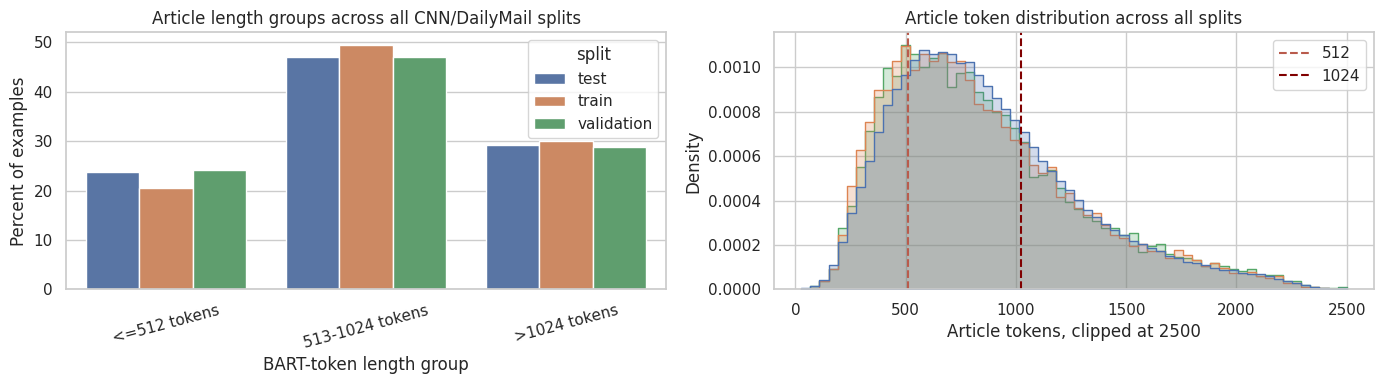

Saved dataset-wide length breakdown: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/dataset_wide_article_length_breakdown.csv
Saved dataset-wide length stats: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/dataset_wide_article_length_stats.csv
Saved plot: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/dataset_wide_article_length_breakdown.png


In [6]:
DATASET_NAME = 'cnn_dailymail'
DATASET_CONFIG = '3.0.0'
RUN_DATASET_WIDE_LENGTH_BREAKDOWN = True

if RUN_DATASET_WIDE_LENGTH_BREAKDOWN:
    try:
        raw_datasets_for_breakdown = load_dataset(DATASET_NAME, DATASET_CONFIG)
    except Exception as exc:
        print('Primary dataset load failed. Trying abisee/cnn_dailymail. Error was:', repr(exc))
        raw_datasets_for_breakdown = load_dataset('abisee/cnn_dailymail', DATASET_CONFIG)

    def is_valid_example(example):
        article = example.get('article', '')
        highlights = example.get('highlights', '')
        return (
            isinstance(article, str)
            and isinstance(highlights, str)
            and len(article.strip()) >= 100
            and len(highlights.strip()) >= 20
        )

    clean_datasets_for_breakdown = raw_datasets_for_breakdown.filter(is_valid_example)
    length_tokenizer = AutoTokenizer.from_pretrained('facebook/bart-base')

    length_frames = []
    for split in clean_datasets_for_breakdown:
        split_ds = clean_datasets_for_breakdown[split]
        def add_lengths(batch):
            article_ids = length_tokenizer(batch['article'], add_special_tokens=True, truncation=False)['input_ids']
            return {'article_tokens': [len(ids) for ids in article_ids]}
        split_lengths = split_ds.map(
            add_lengths,
            batched=True,
            batch_size=256,
            remove_columns=split_ds.column_names,
            desc=f'Counting BART tokens for {split}',
        ).to_pandas()
        split_lengths['split'] = split
        length_frames.append(split_lengths)

    dataset_length_df = pd.concat(length_frames, ignore_index=True)
    dataset_length_df['length_group'] = pd.cut(
        dataset_length_df['article_tokens'],
        bins=[0, 512, 1024, float('inf')],
        labels=['<=512 tokens', '513-1024 tokens', '>1024 tokens'],
        include_lowest=True,
    )

    dataset_breakdown = (
        dataset_length_df
        .groupby(['split', 'length_group'], observed=True)
        .size()
        .reset_index(name='num_examples')
    )
    split_totals = dataset_breakdown.groupby('split')['num_examples'].transform('sum')
    dataset_breakdown['pct_examples'] = dataset_breakdown['num_examples'] / split_totals * 100

    dataset_stats = dataset_length_df.groupby('split')['article_tokens'].agg(
        num_examples='count', mean='mean', median='median', p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90), p95=lambda s: s.quantile(0.95), max='max'
    ).round(2).reset_index()

    breakdown_path = EXT_RESULTS_DIR / 'dataset_wide_article_length_breakdown.csv'
    stats_path = EXT_RESULTS_DIR / 'dataset_wide_article_length_stats.csv'
    plot_path = EXT_RESULTS_DIR / 'dataset_wide_article_length_breakdown.png'
    dataset_breakdown.to_csv(breakdown_path, index=False)
    dataset_stats.to_csv(stats_path, index=False)

    display(dataset_stats)
    display(dataset_breakdown)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=dataset_breakdown, x='length_group', y='pct_examples', hue='split', ax=axes[0])
    axes[0].set_title('Article length groups across all CNN/DailyMail splits')
    axes[0].set_xlabel('BART-token length group')
    axes[0].set_ylabel('Percent of examples')
    axes[0].tick_params(axis='x', rotation=15)

    sns.histplot(data=dataset_length_df, x=dataset_length_df['article_tokens'].clip(upper=2500), hue='split', bins=60, element='step', stat='density', common_norm=False, ax=axes[1])
    axes[1].axvline(512, color='#B95B4C', linestyle='--', label='512')
    axes[1].axvline(1024, color='#800000', linestyle='--', label='1024')
    axes[1].set_title('Article token distribution across all splits')
    axes[1].set_xlabel('Article tokens, clipped at 2500')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=160, bbox_inches='tight')
    plt.show()

    print('Saved dataset-wide length breakdown:', breakdown_path)
    print('Saved dataset-wide length stats:', stats_path)
    print('Saved plot:', plot_path)
else:
    print('Dataset-wide length breakdown skipped.')

## Load the Same Long-Article Set for Every Method

By default, this notebook evaluates **all** examples longer than 1024 BART tokens from the current `test_predictions_with_lengths.csv` file. This keeps Notebook 02 aligned with the same test subset evaluated in Notebook 01.

In [7]:
pred_df = pd.read_csv(PREDICTIONS_PATH)
long_df = pred_df[pred_df['length_group'] == '>1024 tokens'].copy()

if LONG_SAMPLE_SIZE is None:
    long_sample = long_df.reset_index(drop=False).rename(columns={'index': 'test_row_id'})
    sample_label = 'all_long_articles'
else:
    long_sample = long_df.sample(n=min(LONG_SAMPLE_SIZE, len(long_df)), random_state=SEED).reset_index(drop=False).rename(columns={'index': 'test_row_id'})
    sample_label = f'sample_{len(long_sample)}'

long_sample_path = EXT_RESULTS_DIR / f'long_article_comparison_{sample_label}.csv'
long_sample.to_csv(long_sample_path, index=False)

print('All prediction examples:', len(pred_df))
print('Long examples >1024 tokens:', len(long_df))
print('Shared comparison set size:', len(long_sample))
print('Saved comparison set:', long_sample_path)
display(long_sample[['test_row_id', 'article_tokens', 'reference', 'lead3_prediction', 'finetuned_bart_prediction']].head())

All prediction examples: 1500
Long examples >1024 tokens: 440
Shared comparison set size: 440
Saved comparison set: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/long_article_comparison_all_long_articles.csv


,test_row_id,article_tokens,reference,lead3_prediction,finetuned_bart_prediction
0,0,1647,CNN's Dr. Sanjay Gupta says we should legalize...,(CNN) I see signs of a revolution everywhere. ...,David Doblin: The medical marijuana revolution...
1,6,1126,Arsene Wenger will have chat with Theo Walcott...,Arsene Wenger admits he is concerned Theo Walc...,Arsenal boss Arsene Wenger will have a heart-t...
2,7,1294,New video features an Australian doctor called...,An Australian doctor is the face of the latest...,An Australian doctor is the face of the latest...
3,8,1639,Fish and chips has believed to be partly Portu...,"As Prime Minister David Cameron puts it, on St...",FEMAIL reveals the seemingly very English thin...
4,11,1212,"David Wheeler: Corinthian, considered a ""preda...",(CNN)Sunday's announcement that Corinthian Col...,"Corinthian, which once enrolled more than 70,0..."


## Reference Coverage / Lost Information Analysis

Truncation only matters if the removed part contains information needed for the reference summary. This analysis checks whether content words and short phrases from the reference highlights appear in the first 1024 BART tokens or only after the 1024-token cutoff.

This is an approximate lexical coverage analysis, not a full semantic entailment test. It is useful for estimating how often truncation may remove summary-relevant evidence.

In [8]:
import re

STOPWORDS = {'the','a','an','and','or','but','if','while','of','to','in','on','for','from','by','with','as','at','is','are','was','were','be','been','being','it','its','this','that','these','those','he','she','they','them','his','her','their','we','you','i','not','no','do','does','did','has','have','had','will','would','can','could','should','may','might','about','into','over','after','before','more','most','than','then','there','here','who','what','when','where','why','how','said','says','say'}

def normalize_words(text):
    words = re.findall(r"[A-Za-z][A-Za-z'-]+", str(text).lower())
    return [w.strip("'-") for w in words if len(w.strip("'-")) >= 4 and w.strip("'-") not in STOPWORDS]

def content_terms(text):
    words = normalize_words(text)
    unigrams = sorted(set(words))
    bigrams = sorted(set(' '.join(pair) for pair in zip(words, words[1:])))
    return unigrams, bigrams

def contains_term(text_lower, term):
    return term in text_lower

def entity_like_phrases(text):
    # Lightweight named-entity proxy: consecutive capitalized words from the reference.
    # This avoids adding a heavyweight NER dependency while still tracking names, places, and organizations.
    candidates = re.findall(r'\b(?:[A-Z][a-z]+|[A-Z]{2,})(?:\s+(?:[A-Z][a-z]+|[A-Z]{2,}))*', str(text))
    cleaned = []
    for phrase in candidates:
        phrase = phrase.strip()
        if len(phrase) >= 3 and phrase.lower() not in STOPWORDS:
            cleaned.append(phrase)
    return sorted(set(cleaned))

coverage_tokenizer = AutoTokenizer.from_pretrained(BART_MODEL_DIR)
coverage_rows = []
for _, row in long_sample.iterrows():
    article = str(row['article'])
    reference = str(row['reference'])
    article_ids = coverage_tokenizer(article, add_special_tokens=False, truncation=False)['input_ids']
    prefix_text = coverage_tokenizer.decode(article_ids[:1024], skip_special_tokens=True).lower()
    tail_text = coverage_tokenizer.decode(article_ids[1024:], skip_special_tokens=True).lower()
    full_text = article.lower()
    ref_terms, ref_phrases = content_terms(reference)
    ref_entities = entity_like_phrases(reference)
    prefix_terms = [t for t in ref_terms if contains_term(prefix_text, t)]
    tail_only_terms = [t for t in ref_terms if (not contains_term(prefix_text, t)) and contains_term(tail_text, t)]
    missing_terms = [t for t in ref_terms if not contains_term(full_text, t)]
    prefix_phrases = [p for p in ref_phrases if contains_term(prefix_text, p)]
    tail_only_phrases = [p for p in ref_phrases if (not contains_term(prefix_text, p)) and contains_term(tail_text, p)]
    prefix_entities = [e for e in ref_entities if contains_term(prefix_text, e.lower())]
    tail_only_entities = [e for e in ref_entities if (not contains_term(prefix_text, e.lower())) and contains_term(tail_text, e.lower())]
    n_terms = max(len(ref_terms), 1)
    n_phrases = max(len(ref_phrases), 1)
    n_entities = max(len(ref_entities), 1)
    coverage_rows.append({
        'test_row_id': row['test_row_id'],
        'article_tokens': row['article_tokens'],
        'num_reference_terms': len(ref_terms),
        'prefix_1024_term_coverage_pct': 100 * len(prefix_terms) / n_terms,
        'tail_only_term_pct': 100 * len(tail_only_terms) / n_terms,
        'missing_from_article_term_pct': 100 * len(missing_terms) / n_terms,
        'num_reference_phrases': len(ref_phrases),
        'prefix_1024_phrase_coverage_pct': 100 * len(prefix_phrases) / n_phrases,
        'tail_only_phrase_pct': 100 * len(tail_only_phrases) / n_phrases,
        'num_reference_entity_like_phrases': len(ref_entities),
        'prefix_1024_entity_coverage_pct': 100 * len(prefix_entities) / n_entities,
        'tail_only_entity_pct': 100 * len(tail_only_entities) / n_entities,
        'tail_only_entities': ', '.join(tail_only_entities[:20]),
        'tail_only_terms': ', '.join(tail_only_terms[:25]),
        'tail_only_phrases': ', '.join(tail_only_phrases[:20]),
    })
coverage_df = pd.DataFrame(coverage_rows)
coverage_summary = coverage_df[['prefix_1024_term_coverage_pct', 'tail_only_term_pct', 'missing_from_article_term_pct', 'prefix_1024_phrase_coverage_pct', 'tail_only_phrase_pct', 'prefix_1024_entity_coverage_pct', 'tail_only_entity_pct']].agg(['mean', 'median']).round(2)
coverage_path = EXT_RESULTS_DIR / f'reference_coverage_lost_information_{len(coverage_df)}.csv'
coverage_summary_path = EXT_RESULTS_DIR / f'reference_coverage_lost_information_summary_{len(coverage_df)}.csv'
coverage_df.to_csv(coverage_path, index=False)
coverage_summary.to_csv(coverage_summary_path)
print('Saved reference coverage analysis:', coverage_path)
print('Saved summary:', coverage_summary_path)
display(coverage_summary)
display(coverage_df.sort_values('tail_only_term_pct', ascending=False).head(10))

Saved reference coverage analysis: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/reference_coverage_lost_information_440.csv
Saved summary: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/reference_coverage_lost_information_summary_440.csv


,prefix_1024_term_coverage_pct,tail_only_term_pct,missing_from_article_term_pct,prefix_1024_phrase_coverage_pct,tail_only_phrase_pct,prefix_1024_entity_coverage_pct,tail_only_entity_pct
mean,79.63,4.06,16.30,20.35,1.19,87.12,2.27
median,81.74,0.00,14.91,18.92,0.00,91.49,0.00


,test_row_id,article_tokens,num_reference_terms,prefix_1024_term_coverage_pct,tail_only_term_pct,missing_from_article_term_pct,num_reference_phrases,prefix_1024_phrase_coverage_pct,tail_only_phrase_pct,num_reference_entity_like_phrases,prefix_1024_entity_coverage_pct,tail_only_entity_pct,tail_only_entities,tail_only_terms,tail_only_phrases
389,1343,2239,40,40.000000,47.500000,12.500000,46,8.695652,8.695652,3,100.000000,0.000000,,"again, appeal, approached, bars, behind, caugh...","behind bars, inciting murder, reportedly tryin..."
245,855,1456,31,35.483871,41.935484,22.580645,31,6.451613,12.903226,5,80.000000,0.000000,,"enjoying, family, fifth, hockey, home, player,...","enjoying renewed, hockey player, renewed popul..."
228,795,1246,25,44.000000,40.000000,16.000000,25,12.000000,8.000000,10,60.000000,30.000000,"Clash, La Liga, Martin Odegaard","bench, clash, debut, five, hope, liga, make, m...","clash against, martin odegaard"
0,0,1647,11,27.272727,36.363636,36.363636,11,9.090909,18.181818,2,50.000000,0.000000,,"because, easy, legalize, nothing","legalize medical, nothing because"
47,170,1539,35,60.000000,34.285714,5.714286,38,5.263158,15.789474,11,81.818182,18.181818,"George, Utah","additional, adults, attention, based, children...","board flight, evaluated upon, landed safely, m..."
127,415,2022,37,48.648649,32.432432,18.918919,40,10.000000,7.500000,11,81.818182,9.090909,Gregory,"assist, brilliant, defenders, deflected, effor...","deflected effort, hope ahead, scoring barcelona"
3,8,1639,16,68.750000,31.250000,0.000000,16,18.750000,12.500000,6,66.666667,33.333333,"Saint George, Syria","born, himself, saint, syria, thought","george himself, saint george"
114,366,1910,27,37.037037,29.629630,33.333333,26,3.846154,15.384615,8,37.500000,0.000000,,"basket, become, case, many, rubbish, sanctimon...","basket case, campaign trail, economic basket, ..."
272,948,1469,20,60.000000,25.000000,15.000000,22,13.636364,0.000000,6,66.666667,16.666667,Tensions,"coalition, invasion, muster, tensions, tried",
13,54,2332,16,43.750000,25.000000,31.250000,16,12.500000,0.000000,4,100.000000,0.000000,,"abolished, following, performance, result",


## Metric and Generation Helpers


In [9]:
rouge_metric = evaluate.load('rouge')
bertscore_metric = evaluate.load('bertscore')


def postprocess_text(preds, refs):
    preds = [str(pred).strip() for pred in preds]
    refs = [str(ref).strip() for ref in refs]
    preds = ['\n'.join(sent_tokenize(pred)) for pred in preds]
    refs = ['\n'.join(sent_tokenize(ref)) for ref in refs]
    return preds, refs


def compute_metrics(preds, refs, label, notes=''):
    metric_preds, metric_refs = postprocess_text(preds, refs)
    rouge = rouge_metric.compute(predictions=metric_preds, references=metric_refs, use_stemmer=True)
    result = {'method': label, 'notes': notes}
    result.update({k: round(v * 100, 4) for k, v in rouge.items()})
    bs = bertscore_metric.compute(
        predictions=list(preds),
        references=list(refs),
        lang='en',
        model_type='roberta-large',
        batch_size=8,
        rescale_with_baseline=True,
    )
    result['bertscore_f1'] = round(float(np.mean(bs['f1']) * 100), 4)
    result['num_examples'] = len(preds)
    return result


def generate_batch(model, tokenizer, texts, max_input_length=1024, max_output_length=128, batch_size=4, use_led_global_attention=False):
    outputs = []
    model.eval()
    for start in tqdm(range(0, len(texts), batch_size), desc='Generating'):
        batch_texts = list(texts[start:start + batch_size])
        inputs = tokenizer(
            batch_texts,
            max_length=max_input_length,
            truncation=True,
            padding=True,
            return_tensors='pt',
        ).to(model.device)
        generate_kwargs = dict(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            num_beams=NUM_BEAMS,
            max_length=max_output_length,
            min_length=MIN_GENERATION_LENGTH,
            no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
            do_sample=False,
        )
        if use_led_global_attention:
            global_attention_mask = torch.zeros_like(inputs['input_ids'])
            global_attention_mask[:, 0] = 1
            generate_kwargs['global_attention_mask'] = global_attention_mask
        with torch.no_grad():
            generated_ids = model.generate(**generate_kwargs)
        outputs.extend(tokenizer.batch_decode(generated_ids, skip_special_tokens=True))
    return outputs


def chunk_article_by_tokens(article, tokenizer, chunk_len=900, stride=700):
    ids = tokenizer(str(article), add_special_tokens=False)['input_ids']
    chunks = []
    if len(ids) <= chunk_len:
        return [str(article)]
    for start in range(0, len(ids), stride):
        chunk_ids = ids[start:start + chunk_len]
        if len(chunk_ids) < 80 and chunks:
            break
        chunks.append(tokenizer.decode(chunk_ids, skip_special_tokens=True))
        if start + chunk_len >= len(ids):
            break
    return chunks


def hierarchical_bart_summary(article, model, tokenizer):
    chunks = chunk_article_by_tokens(article, tokenizer, CHUNK_TOKEN_LENGTH, CHUNK_STRIDE)
    chunk_summaries = generate_batch(
        model,
        tokenizer,
        chunks,
        max_input_length=1024,
        max_output_length=CHUNK_SUMMARY_MAX_LENGTH,
        batch_size=4,
    )
    combined = ' '.join(chunk_summaries)
    final_summary = generate_batch(
        model,
        tokenizer,
        [combined],
        max_input_length=1024,
        max_output_length=FINAL_SUMMARY_MAX_LENGTH,
        batch_size=1,
    )[0]
    return final_summary, len(chunks), combined


def save_metrics_table(rows, suffix):
    metrics_df = pd.DataFrame(rows)
    metrics_path = EXT_RESULTS_DIR / f'long_article_comparison_metrics_{suffix}.csv'
    metrics_df.to_csv(metrics_path, index=False)
    print('Saved metrics:', metrics_path)
    display(metrics_df)
    return metrics_df, metrics_path


## Baselines Already Available from the Main Notebook

These are included in the final comparison without rerunning generation:

- Lead-3
- Fine-tuned BART-base with 1024-token truncation


In [10]:
base_comparison_df = long_sample[[
    'test_row_id', 'article_tokens', 'article', 'reference', 'lead3_prediction', 'finetuned_bart_prediction'
]].copy()
base_comparison_df = base_comparison_df.rename(columns={'finetuned_bart_prediction': 'bart_truncated_prediction'})
comparison_path = EXT_RESULTS_DIR / f'long_article_comparison_predictions_{len(base_comparison_df)}.csv'

if comparison_path.exists():
    existing_df = pd.read_csv(comparison_path)
    if len(existing_df) == len(base_comparison_df) and set(base_comparison_df['test_row_id']) == set(existing_df['test_row_id']):
        comparison_df = existing_df
        print('Loaded existing comparison file and will resume from it:', comparison_path)
    else:
        comparison_df = base_comparison_df
        comparison_df.to_csv(comparison_path, index=False)
        print('Existing comparison file did not match current set; initialized a new comparison file:', comparison_path)
else:
    comparison_df = base_comparison_df
    comparison_df.to_csv(comparison_path, index=False)
    print('Initialized comparison predictions:', comparison_path)

display(comparison_df.head())

Loaded existing comparison file and will resume from it: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/long_article_comparison_predictions_440.csv


,test_row_id,article_tokens,article,reference,lead3_prediction,bart_truncated_prediction,hierarchical_bart_prediction,hierarchical_num_chunks,hierarchical_combined_chunk_summaries
0,0,1647,(CNN) I see signs of a revolution everywhere. ...,CNN's Dr. Sanjay Gupta says we should legalize...,(CNN) I see signs of a revolution everywhere. ...,David Doblin: The medical marijuana revolution...,Rick Doblin: The medical marijuana revolution ...,3.0,Rick Doblin: The medical marijuana revolution ...
1,6,1126,Arsene Wenger admits he is concerned Theo Walc...,Arsene Wenger will have chat with Theo Walcott...,Arsene Wenger admits he is concerned Theo Walc...,Arsenal boss Arsene Wenger will have a heart-t...,Arsenal boss Arsene Wenger will have a heart-t...,2.0,Arsenal boss Arsene Wenger will have a heart-t...
2,7,1294,An Australian doctor is the face of the latest...,New video features an Australian doctor called...,An Australian doctor is the face of the latest...,An Australian doctor is the face of the latest...,An Australian doctor is the face of the latest...,2.0,An Australian doctor is the face of the latest...
3,8,1639,"As Prime Minister David Cameron puts it, on St...",Fish and chips has believed to be partly Portu...,"As Prime Minister David Cameron puts it, on St...",FEMAIL reveals the seemingly very English thin...,FEMAIL reveals the seemingly very English thin...,3.0,FEMAIL reveals the seemingly very English thin...
4,11,1212,(CNN)Sunday's announcement that Corinthian Col...,"David Wheeler: Corinthian, considered a ""preda...",(CNN)Sunday's announcement that Corinthian Col...,"Corinthian, which once enrolled more than 70,0...","Corinthian, which once enrolled more than 70,0...",2.0,"Corinthian, which once enrolled more than 70,0..."


## Run Hierarchical Fine-Tuned BART

This method uses the same fine-tuned BART checkpoint but changes the inference strategy to reduce information loss from long articles.


In [11]:
bart_tokenizer = AutoTokenizer.from_pretrained(BART_MODEL_DIR)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(BART_MODEL_DIR).to(DEVICE)
bart_model.eval()

if RUN_HIERARCHICAL_BART:
    comparison_df = pd.read_csv(comparison_path)
    for col in ['hierarchical_bart_prediction', 'hierarchical_num_chunks', 'hierarchical_combined_chunk_summaries']:
        if col not in comparison_df.columns:
            comparison_df[col] = pd.NA

    missing_idx = comparison_df.index[comparison_df['hierarchical_bart_prediction'].isna()].tolist()
    print(f'Hierarchical BART missing predictions: {len(missing_idx)}/{len(comparison_df)}')
    start_time = time.time()
    for count, idx in enumerate(tqdm(missing_idx, desc='Hierarchical BART'), start=1):
        row = comparison_df.loc[idx]
        pred, num_chunks, combined = hierarchical_bart_summary(row['article'], bart_model, bart_tokenizer)
        comparison_df.at[idx, 'hierarchical_bart_prediction'] = pred
        comparison_df.at[idx, 'hierarchical_num_chunks'] = num_chunks
        comparison_df.at[idx, 'hierarchical_combined_chunk_summaries'] = combined
        if count % 25 == 0 or count == len(missing_idx):
            comparison_df.to_csv(comparison_path, index=False)
            progress_path = EXT_RESULTS_DIR / f'hierarchical_bart_progress_{comparison_df["hierarchical_bart_prediction"].notna().sum()}_of_{len(comparison_df)}.csv'
            comparison_df.to_csv(progress_path, index=False)
            print(f'Saved hierarchical progress: {comparison_df["hierarchical_bart_prediction"].notna().sum()}/{len(comparison_df)}')
    comparison_df.to_csv(comparison_path, index=False)
    print('Hierarchical runtime minutes:', round((time.time() - start_time) / 60, 2))
else:
    print('Skipping hierarchical BART.')

display(comparison_df.head())

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Hierarchical BART missing predictions: 115/440


Hierarchical BART:   0%|          | 0/115 [00:00<?, ?it/s]

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

...

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Saved hierarchical progress: 440/440
Hierarchical runtime minutes: 3.33


,test_row_id,article_tokens,article,reference,lead3_prediction,bart_truncated_prediction,hierarchical_bart_prediction,hierarchical_num_chunks,hierarchical_combined_chunk_summaries
0,0,1647,(CNN) I see signs of a revolution everywhere. ...,CNN's Dr. Sanjay Gupta says we should legalize...,(CNN) I see signs of a revolution everywhere. ...,David Doblin: The medical marijuana revolution...,Rick Doblin: The medical marijuana revolution ...,3.0,Rick Doblin: The medical marijuana revolution ...
1,6,1126,Arsene Wenger admits he is concerned Theo Walc...,Arsene Wenger will have chat with Theo Walcott...,Arsene Wenger admits he is concerned Theo Walc...,Arsenal boss Arsene Wenger will have a heart-t...,Arsenal boss Arsene Wenger will have a heart-t...,2.0,Arsenal boss Arsene Wenger will have a heart-t...
2,7,1294,An Australian doctor is the face of the latest...,New video features an Australian doctor called...,An Australian doctor is the face of the latest...,An Australian doctor is the face of the latest...,An Australian doctor is the face of the latest...,2.0,An Australian doctor is the face of the latest...
3,8,1639,"As Prime Minister David Cameron puts it, on St...",Fish and chips has believed to be partly Portu...,"As Prime Minister David Cameron puts it, on St...",FEMAIL reveals the seemingly very English thin...,FEMAIL reveals the seemingly very English thin...,3.0,FEMAIL reveals the seemingly very English thin...
4,11,1212,(CNN)Sunday's announcement that Corinthian Col...,"David Wheeler: Corinthian, considered a ""preda...",(CNN)Sunday's announcement that Corinthian Col...,"Corinthian, which once enrolled more than 70,0...","Corinthian, which once enrolled more than 70,0...",2.0,"Corinthian, which once enrolled more than 70,0..."


## Run Longer-Context Model(s)

Default model: `CyrexPro/led-base-16384-finetuned-cnn_dailymail` with 4096-token input.

Important: this tests the longer-context idea. If the checkpoint is not fine-tuned on CNN/DailyMail, do not claim it is a fair replacement for the fine-tuned BART model. Treat it as a long-context probe.


In [12]:
if RUN_LONG_CONTEXT_MODELS:
    comparison_df = pd.read_csv(comparison_path)
    for spec in LONG_CONTEXT_MODEL_SPECS:
        label = spec['label']
        model_name = spec['model_name']
        safe_label = label.lower().replace(' ', '_').replace('/', '_').replace('-', '_')
        pred_col = f'{safe_label}_prediction'
        if pred_col not in comparison_df.columns:
            comparison_df[pred_col] = pd.NA
        missing_idx = comparison_df.index[comparison_df[pred_col].isna()].tolist()
        print('Running long-context model:', label, model_name)
        print(f'Missing predictions for {label}: {len(missing_idx)}/{len(comparison_df)}')
        if not missing_idx:
            continue
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        lc_tokenizer = AutoTokenizer.from_pretrained(model_name)
        lc_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(DEVICE)
        lc_model.eval()
        is_led = 'led' in model_name.lower() or 'LED' in lc_model.__class__.__name__
        batch_size = spec.get('batch_size', 1)
        for start in tqdm(range(0, len(missing_idx), batch_size), desc=f'Generating {label}'):
            batch_idx = missing_idx[start:start + batch_size]
            batch_texts = comparison_df.loc[batch_idx, 'article'].tolist()
            preds = generate_batch(
                lc_model,
                lc_tokenizer,
                batch_texts,
                max_input_length=spec.get('max_input_length', 4096),
                max_output_length=128,
                batch_size=batch_size,
                use_led_global_attention=is_led,
            )
            for idx, pred in zip(batch_idx, preds):
                comparison_df.at[idx, pred_col] = pred
            if (start + len(batch_idx)) % 25 == 0 or start + len(batch_idx) >= len(missing_idx):
                comparison_df.to_csv(comparison_path, index=False)
                progress_path = EXT_RESULTS_DIR / f'{safe_label}_progress_{comparison_df[pred_col].notna().sum()}_of_{len(comparison_df)}.csv'
                comparison_df.to_csv(progress_path, index=False)
                print(f'Saved {label} progress: {comparison_df[pred_col].notna().sum()}/{len(comparison_df)}')
        comparison_df.to_csv(comparison_path, index=False)
        print('Saved predictions after:', label)
        del lc_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
else:
    print('Skipping longer-context models.')

display(comparison_df.head())

Running long-context model: Fine-tuned LED-base-16384 CNN/DM CyrexPro/led-base-16384-finetuned-cnn_dailymail
Missing predictions for Fine-tuned LED-base-16384 CNN/DM: 440/440


config.json:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[transformers] Input ids are automatically padded from 1404 to 2048 to be a multiple of `config.attention_window`: 1024


Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Fine-tuned LED-base-16384 CNN/DM progress: 440/440
Saved predictions after: Fine-tuned LED-base-16384 CNN/DM


,test_row_id,article_tokens,article,reference,lead3_prediction,bart_truncated_prediction,hierarchical_bart_prediction,hierarchical_num_chunks,hierarchical_combined_chunk_summaries,fine_tuned_led_base_16384_cnn_dm_prediction
0,0,1647,(CNN) I see signs of a revolution everywhere. ...,CNN's Dr. Sanjay Gupta says we should legalize...,(CNN) I see signs of a revolution everywhere. ...,David Doblin: The medical marijuana revolution...,Rick Doblin: The medical marijuana revolution ...,3.0,Rick Doblin: The medical marijuana revolution ...,marijuana is a medicine that should be studied...
1,6,1126,Arsene Wenger admits he is concerned Theo Walc...,Arsene Wenger will have chat with Theo Walcott...,Arsene Wenger admits he is concerned Theo Walc...,Arsenal boss Arsene Wenger will have a heart-t...,Arsenal boss Arsene Wenger will have a heart-t...,2.0,Arsenal boss Arsene Wenger will have a heart-t...,Theo Walcott struggled for England in their 1...
2,7,1294,An Australian doctor is the face of the latest...,New video features an Australian doctor called...,An Australian doctor is the face of the latest...,An Australian doctor is the face of the latest...,An Australian doctor is the face of the latest...,2.0,An Australian doctor is the face of the latest...,"in the video, a man with an australian accent ..."
3,8,1639,"As Prime Minister David Cameron puts it, on St...",Fish and chips has believed to be partly Portu...,"As Prime Minister David Cameron puts it, on St...",FEMAIL reveals the seemingly very English thin...,FEMAIL reveals the seemingly very English thin...,3.0,FEMAIL reveals the seemingly very English thin...,the bag was invented by a 13-year-old boy in t...
4,11,1212,(CNN)Sunday's announcement that Corinthian Col...,"David Wheeler: Corinthian, considered a ""preda...",(CNN)Sunday's announcement that Corinthian Col...,"Corinthian, which once enrolled more than 70,0...","Corinthian, which once enrolled more than 70,0...",2.0,"Corinthian, which once enrolled more than 70,0...","Corinthian colleges, the largest for-profit c..."


## BART-Large-CNN Reference

This is a stronger CNN/DailyMail summarization model, but it is **not** a longer-context model. Use it only as an extra reference.


In [13]:
if RUN_BART_LARGE_CNN_REFERENCE:
    comparison_df = pd.read_csv(comparison_path)
    ref_col = 'bart_large_cnn_reference_prediction'
    if ref_col not in comparison_df.columns:
        comparison_df[ref_col] = pd.NA
    missing_idx = comparison_df.index[comparison_df[ref_col].isna()].tolist()
    print(f'BART-large-CNN missing predictions: {len(missing_idx)}/{len(comparison_df)}')
    if missing_idx:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        ref_name = 'facebook/bart-large-cnn'
        ref_tokenizer = AutoTokenizer.from_pretrained(ref_name)
        ref_model = AutoModelForSeq2SeqLM.from_pretrained(ref_name).to(DEVICE)
        batch_size = 2
        for start in tqdm(range(0, len(missing_idx), batch_size), desc='Generating BART-large-CNN'):
            batch_idx = missing_idx[start:start + batch_size]
            batch_texts = comparison_df.loc[batch_idx, 'article'].tolist()
            preds = generate_batch(ref_model, ref_tokenizer, batch_texts, max_input_length=1024, max_output_length=128, batch_size=batch_size)
            for idx, pred in zip(batch_idx, preds):
                comparison_df.at[idx, ref_col] = pred
            if (start + len(batch_idx)) % 50 == 0 or start + len(batch_idx) >= len(missing_idx):
                comparison_df.to_csv(comparison_path, index=False)
                progress_path = EXT_RESULTS_DIR / f'bart_large_cnn_progress_{comparison_df[ref_col].notna().sum()}_of_{len(comparison_df)}.csv'
                comparison_df.to_csv(progress_path, index=False)
                print(f'Saved BART-large-CNN progress: {comparison_df[ref_col].notna().sum()}/{len(comparison_df)}')
        comparison_df.to_csv(comparison_path, index=False)
else:
    print('Skipping BART-large-CNN reference.')

BART-large-CNN missing predictions: 440/440


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Saved BART-large-CNN progress: 440/440


## Unified Metrics Table

This is the table to use in the report/PPT. Every method is evaluated on the same long-article sample.


In [14]:
comparison_df = pd.read_csv(comparison_path)
refs = comparison_df['reference'].tolist()
rows = []
rows.append(compute_metrics(comparison_df['lead3_prediction'].tolist(), refs, 'Lead-3 baseline', 'Extractive baseline; first three sentences'))
rows.append(compute_metrics(comparison_df['bart_truncated_prediction'].tolist(), refs, 'Fine-tuned BART-base, 1024-token truncation', 'Main model from original notebook'))

if 'hierarchical_bart_prediction' in comparison_df.columns:
    rows.append(compute_metrics(comparison_df['hierarchical_bart_prediction'].tolist(), refs, 'Hierarchical fine-tuned BART', 'Chunk long article, summarize chunks, summarize combined chunk summaries'))

for spec in LONG_CONTEXT_MODEL_SPECS:
    safe_label = spec['label'].lower().replace(' ', '_').replace('/', '_').replace('-', '_')
    pred_col = f'{safe_label}_prediction'
    if pred_col in comparison_df.columns:
        rows.append(compute_metrics(comparison_df[pred_col].tolist(), refs, spec['label'], spec.get('notes', 'Long-context model')))

if 'bart_large_cnn_reference_prediction' in comparison_df.columns:
    rows.append(compute_metrics(comparison_df['bart_large_cnn_reference_prediction'].tolist(), refs, 'BART-large-CNN reference', 'Stronger CNN/DM model; not long-context'))

metrics_df, metrics_path = save_metrics_table(rows, f'{len(comparison_df)}')
metrics_df

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/bert_score/scorer.py:139: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable befor

Saved metrics: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/long_article_comparison_metrics_440.csv


,method,notes,rouge1,rouge2,rougeL,rougeLsum,bertscore_f1,num_examples
0,Lead-3 baseline,Extractive baseline; first three sentences,37.0630,14.1811,21.9925,33.4335,19.3308,440
1,"Fine-tuned BART-base, 1024-token truncation",Main model from original notebook,38.8189,15.8185,25.1670,35.7281,27.4355,440
2,Hierarchical fine-tuned BART,"Chunk long article, summarize chunks, summariz...",36.6385,14.0029,23.6335,33.5842,24.8547,440
3,Fine-tuned LED-base-16384 CNN/DM,Long-context LED model fine-tuned on CNN/Daily...,32.7555,10.9999,21.2256,30.1644,16.4420,440
4,BART-large-CNN reference,Stronger CNN/DM model; not long-context,41.6900,18.1841,28.0201,38.6494,26.2091,440


,method,notes,rouge1,rouge2,rougeL,rougeLsum,bertscore_f1,num_examples
0,Lead-3 baseline,Extractive baseline; first three sentences,37.0630,14.1811,21.9925,33.4335,19.3308,440
1,"Fine-tuned BART-base, 1024-token truncation",Main model from original notebook,38.8189,15.8185,25.1670,35.7281,27.4355,440
2,Hierarchical fine-tuned BART,"Chunk long article, summarize chunks, summariz...",36.6385,14.0029,23.6335,33.5842,24.8547,440
3,Fine-tuned LED-base-16384 CNN/DM,Long-context LED model fine-tuned on CNN/Daily...,32.7555,10.9999,21.2256,30.1644,16.4420,440
4,BART-large-CNN reference,Stronger CNN/DM model; not long-context,41.6900,18.1841,28.0201,38.6494,26.2091,440


## Qualitative Export for Factual Consistency Review

This exports a smaller side-by-side table so you can manually inspect factual consistency for all methods.


In [15]:
qual_cols = ['test_row_id', 'article_tokens', 'article', 'reference', 'lead3_prediction', 'bart_truncated_prediction']
for col in comparison_df.columns:
    if col.endswith('_prediction') and col not in qual_cols:
        qual_cols.append(col)
qual_df = comparison_df[qual_cols].copy()
qual_path = EXT_RESULTS_DIR / f'long_article_comparison_for_factual_review_{len(qual_df)}.csv'
qual_df.to_csv(qual_path, index=False)
print('Saved qualitative/factual review file:', qual_path)
display(qual_df.head())

Saved qualitative/factual review file: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/long_article_comparison_for_factual_review_440.csv


,test_row_id,article_tokens,article,reference,lead3_prediction,bart_truncated_prediction,hierarchical_bart_prediction,fine_tuned_led_base_16384_cnn_dm_prediction,bart_large_cnn_reference_prediction
0,0,1647,(CNN) I see signs of a revolution everywhere. ...,CNN's Dr. Sanjay Gupta says we should legalize...,(CNN) I see signs of a revolution everywhere. ...,David Doblin: The medical marijuana revolution...,Rick Doblin: The medical marijuana revolution ...,marijuana is a medicine that should be studied...,CNN's John Sutter says he sees signs of a medi...
1,6,1126,Arsene Wenger admits he is concerned Theo Walc...,Arsene Wenger will have chat with Theo Walcott...,Arsene Wenger admits he is concerned Theo Walc...,Arsenal boss Arsene Wenger will have a heart-t...,Arsenal boss Arsene Wenger will have a heart-t...,Theo Walcott struggled for England in their 1...,Theo Walcott was replaced after 55 minutes of ...
2,7,1294,An Australian doctor is the face of the latest...,New video features an Australian doctor called...,An Australian doctor is the face of the latest...,An Australian doctor is the face of the latest...,An Australian doctor is the face of the latest...,"in the video, a man with an australian accent ...",An Australian doctor is the face of the latest...
3,8,1639,"As Prime Minister David Cameron puts it, on St...",Fish and chips has believed to be partly Portu...,"As Prime Minister David Cameron puts it, on St...",FEMAIL reveals the seemingly very English thin...,FEMAIL reveals the seemingly very English thin...,the bag was invented by a 13-year-old boy in t...,FEMAIL reveals the things that have actually b...
4,11,1212,(CNN)Sunday's announcement that Corinthian Col...,"David Wheeler: Corinthian, considered a ""preda...",(CNN)Sunday's announcement that Corinthian Col...,"Corinthian, which once enrolled more than 70,0...","Corinthian, which once enrolled more than 70,0...","Corinthian colleges, the largest for-profit c...",Gloria Borger: Corinthian Colleges Inc. is one...


## Full Side-by-Side Examples

This prints three complete examples using the same source articles across all methods. It also saves a markdown file so the outputs are not truncated by the notebook display.


In [16]:
# Pick three examples from the shared comparison set and print full outputs.
# You can change these row positions if you want different examples.
example_positions = [0, 1, 2]
comparison_df = pd.read_csv(comparison_path)

method_cols = [
    ('Lead-3', 'lead3_prediction'),
    ('Fine-tuned BART-base, truncated', 'bart_truncated_prediction'),
]
if 'hierarchical_bart_prediction' in comparison_df.columns:
    method_cols.append(('Hierarchical BART', 'hierarchical_bart_prediction'))
for col in comparison_df.columns:
    if col.endswith('_prediction') and col not in [m[1] for m in method_cols] and col not in ['lead3_prediction', 'bart_truncated_prediction']:
        method_cols.append((col.replace('_prediction', '').replace('_', ' '), col))

lines = ['# Full Side-by-Side Examples', '']
for n, pos in enumerate(example_positions, start=1):
    row = comparison_df.iloc[pos]
    lines.append(f'## Example {n}: test row {row.test_row_id}, {row.article_tokens} tokens')
    lines.append('')
    lines.append('### Article')
    lines.append(str(row.article).strip())
    lines.append('')
    lines.append('### Human Reference')
    lines.append(str(row.reference).strip())
    lines.append('')
    for label, col in method_cols:
        if col in comparison_df.columns:
            lines.append(f'### {label}')
            lines.append(str(row[col]).strip())
            lines.append('')
    lines.append('---')
    lines.append('')

examples_path = EXT_RESULTS_DIR / f'full_side_by_side_examples_{len(comparison_df)}.md'
examples_path.write_text('\n'.join(lines), encoding='utf-8')
print('Saved full examples to:', examples_path)
print('\n'.join(lines[:220]))


Saved full examples to: /content/drive/MyDrive/ML2Final/ml2_final_bart/bart_base_cnn_dm_train50000_src1024_epochs2/results/extension_long_context/full_side_by_side_examples_440.md
# Full Side-by-Side Examples

## Example 1: test row 0, 1647 tokens

### Article
(CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it safe with this explosive issue but are now willing to stake their political futures on it. I see the revolution in the eyes of sterling scientists, previously reluctant to dip a toe into this heavily stigmatized world, who are diving in head first. I see it in the new surgeon general who cites data showing just how helpful it can be. I see a revolution in the attitudes of everyday Americans. For the first time a majority, 53%, favor its legalization, with 77% supporting it for medical purposes. Support for legalization has risen 11 p

## Report/PPT Interpretation

Suggested interpretation:

> Since 1024 tokens still truncates about 30% of CNN/DailyMail articles, we added an extension experiment on articles longer than 1024 tokens. We compared Lead-3, our fine-tuned BART with standard truncation, a hierarchical BART inference strategy, and a longer-context model on the same long-article subset.

If hierarchical improves:

> Hierarchical summarization partially reduces information loss from truncation.

If longer-context improves:

> Longer input capacity can help recover information from later parts of the article.

If either method does not improve:

> Simply increasing context or chunking does not automatically solve summarization quality; model pretraining/fine-tuning domain and intermediate-summary noise also matter.
